# Notebook 06: Retrieval Strategies

**Time:** ~35 minutes  
**Goal:** Beat naive top-k cosine. Implement and benchmark four advanced retrieval techniques.

This notebook will:
1. Establish a dense baseline (top-k cosine over FAISS)
2. Add **BM25** sparse retrieval
3. Build **hybrid search** with **Reciprocal Rank Fusion** (the 2026 default)
4. Add **HyDE** (Hypothetical Document Embeddings) — fix question/answer asymmetry
5. Add **MMR** (Maximal Marginal Relevance) — diversify results to fight redundancy
6. Use **multi-query rewriting** — let an LLM generate paraphrases

> **The lesson of 2024-26 RAG research:** the embedding model rarely matters as much as your retrieval *strategy*. Hybrid + reranking can beat changing models.


## Setup


In [1]:
import os, sys, time, importlib, json
from pathlib import Path

notebook_dir = os.getcwd()
parent_dir   = str(Path(notebook_dir).parent)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

from dotenv import load_dotenv
load_dotenv(os.path.join(parent_dir, '.env'), override=True)

import src.llm_client, src.cost_tracker, src.utils, src.config
import src.document_loader, src.chunking, src.embeddings, src.vector_store, src.retrieval
for mod in [src.llm_client, src.cost_tracker, src.utils, src.config,
            src.document_loader, src.chunking, src.embeddings,
            src.vector_store, src.retrieval]:
    importlib.reload(mod)

from src.llm_client import LLMClient
from src.cost_tracker import CostTracker
from src.utils import format_response, append_to_reflection
from src.document_loader import load_directory
from src.chunking import recursive_chunk
from src.embeddings import EmbeddingModel
from src.vector_store import FAISSStore
from src.retrieval import (
    BM25Retriever, HybridRetriever, reciprocal_rank_fusion,
    mmr_search, hyde_retrieve, rewrite_query,
)
import src.config as config

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

client  = LLMClient(path=config.PATH)
tracker = CostTracker()

outputs_dir = os.path.join('..', 'outputs')
test_data   = os.path.join('..', 'test_data')

print('Setup complete -- ready for Notebook 06')


✓ Claude API client initialized
  Default model: claude-sonnet-4-6
  Available: claude-sonnet-4-6, claude-opus-4-6, claude-haiku-4-5-20251001
Setup complete -- ready for Notebook 06


## Build the index once


In [2]:
my_docs = load_directory(os.path.join(test_data, 'my_corpus'))
chunks = []
for d in my_docs:
    for i, c in enumerate(recursive_chunk(d['text'], chunk_size=500, overlap=50)):
        chunks.append({'text': c, 'metadata': {'source': os.path.basename(d['source']), 'chunk_id': i}})
print(f'{len(chunks)} chunks across {len(my_docs)} docs')

em = EmbeddingModel('all-MiniLM-L6-v2')
vecs = em.encode([c['text'] for c in chunks])

faiss_store = FAISSStore(dim=em.dim)
faiss_store.add(chunks, vecs)

bm25 = BM25Retriever(chunks)


  ✓ Loaded portfolio_notes.txt: 2,669 chars
  ✓ Loaded sample_resume.pdf: 1 pages, 2,082 chars (via pymupdf)

✓ Loaded 2 documents from ..\test_data\my_corpus
  ✓ recursive_chunk: 8 chunks (size~500, overlap=50)
  ✓ recursive_chunk: 5 chunks (size~500, overlap=50)
  ✓ recursive_chunk: 5 chunks (size~500, overlap=50)
13 chunks across 2 docs
  Loading all-MiniLM-L6-v2 (sentence-transformers, cpu)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  ✓ Loaded in 1.2s, dim=384
  ✓ FAISS: 13 vectors added (total: 13)
  ✓ BM25 indexed 13 chunks


c:\Users\lflyl\OneDrive\文档\inferenceai\week4\Homework4-Submission\src\embeddings.py:83: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  self._dim = self._client.get_sentence_embedding_dimension()


## Part 1 — Baseline: dense top-k cosine


In [18]:
QUERY = 'What ML frameworks does this candidate know?'
qv = em.encode_query(QUERY) if hasattr(em, 'encode_query') else em.encode(QUERY)

print('=' * 65)
print(f'Baseline: dense top-3 for: {QUERY!r}')
print('=' * 65)
for r in faiss_store.search(qv, k=3):
    print(f'  [{r["score"]:.3f}] {r["metadata"]["source"]}::{r["metadata"]["chunk_id"]}')
    print(f'    {r["text"][:140]}...\n')


Baseline: dense top-3 for: 'What ML frameworks does this candidate know?'
  [0.365] portfolio_notes.txt::4
    ports by 11%.

## Data Pipelines & Product InsightOne of my biggest technical wins was ingesting and transforming large datasets at DoorDash...

  [0.332] sample_resume.pdf::3
    ilt out a unit testing infrastructure for a clientilt out a unit testing infrastructure for a clientweb application that reduced the number ...

  [0.317] sample_resume.pdf::0
    GIULIA
GONZALEZ
Python Developer
ggonzalez@email.com
(123) 456-7890
Detroit, MI
LinkedIn
Github
EDUCATION
M.S.
Computer Science
University o...



## Part 2 — BM25 sparse


In [5]:
print('=' * 65)
print(f'BM25 top-3 for: {QUERY!r}')
print('=' * 65)
for r in bm25.search(QUERY, k=3):
    print(f'  [{r["score"]:.2f}] {r["metadata"]["source"]}::{r["metadata"]["chunk_id"]}')
    print(f'    {r["text"][:140]}...\n')


BM25 top-3 for: 'What ML frameworks does this candidate know?'


## Part 3 — Hybrid retrieval with Reciprocal Rank Fusion (RRF)

RRF: each doc's score = Σ 1 / (k + rank). Robust to score-scale differences. The 2026 production default.


In [6]:
hybrid = HybridRetriever(faiss_store, em, bm25)

print('=' * 65)
print(f'Hybrid (dense+BM25, RRF) top-3 for: {QUERY!r}')
print('=' * 65)
for r in hybrid.search(QUERY, k=3):
    print(f'  [RRF={r["score"]:.4f}] {r["metadata"]["source"]}::{r["metadata"]["chunk_id"]}')
    print(f'    {r["text"][:140]}...\n')


Hybrid (dense+BM25, RRF) top-3 for: 'What ML frameworks does this candidate know?'
  Hybrid: dense=12 sparse=0 -> fused=3
  [RRF=0.0164] portfolio_notes.txt::4
    ports by 11%.

## Data Pipelines & Product InsightOne of my biggest technical wins was ingesting and transforming large datasets at DoorDash...

  [RRF=0.0161] sample_resume.pdf::3
    ilt out a unit testing infrastructure for a clientilt out a unit testing infrastructure for a clientweb application that reduced the number ...

  [RRF=0.0159] sample_resume.pdf::0
    GIULIA
GONZALEZ
Python Developer
ggonzalez@email.com
(123) 456-7890
Detroit, MI
LinkedIn
Github
EDUCATION
M.S.
Computer Science
University o...



## Part 4 — HyDE: ask the LLM to write the answer first, then search for THAT


In [7]:
print('=' * 65)
print(f'HyDE top-3 for: {QUERY!r}')
print('=' * 65)
hyde_results = hyde_retrieve(faiss_store, em, client, QUERY, k=3, num_hypotheses=2)
for r in hyde_results:
    print(f'  [{r["score"]:.3f}] {r["metadata"]["source"]}::{r["metadata"]["chunk_id"]}')
    print(f'    {r["text"][:140]}...\n')


HyDE top-3 for: 'What ML frameworks does this candidate know?'
  HyDE generated 2 hypothetical answer(s)
  [0.426] sample_resume.pdf::0
    GIULIA
GONZALEZ
Python Developer
ggonzalez@email.com
(123) 456-7890
Detroit, MI
LinkedIn
Github
EDUCATION
M.S.
Computer Science
University o...

  [0.397] portfolio_notes.txt::0
    ## Career Summary

I'm a Python developer with a strong foundation in backend development, frontend components, and scalable data workflows....

  [0.382] portfolio_notes.txt::4
    ports by 11%.

## Data Pipelines & Product InsightOne of my biggest technical wins was ingesting and transforming large datasets at DoorDash...



## Part 5 — MMR for diversity

Pure top-k can return three near-duplicate chunks. MMR penalizes similarity to already-selected results.


In [8]:
print('=' * 65)
print(f'MMR (lambda=0.5) top-5 for: {QUERY!r}')
print('=' * 65)
mmr_results = mmr_search(faiss_store, em, QUERY, k=5, fetch_k=20, lambda_mult=0.5)
for r in mmr_results:
    print(f'  rank={r["rank"]} {r["metadata"]["source"]}::{r["metadata"]["chunk_id"]}')
    print(f'    {r["text"][:140]}...\n')


MMR (lambda=0.5) top-5 for: 'What ML frameworks does this candidate know?'
  rank=1 portfolio_notes.txt::4
    ports by 11%.

## Data Pipelines & Product InsightOne of my biggest technical wins was ingesting and transforming large datasets at DoorDash...

  rank=2 portfolio_notes.txt::6
    ficient.

## Communication & Stakeholder AlignmentI frequently interfaced with internal stakeholders—PMs, designers, and data scientists—to ...

  rank=3 sample_resume.pdf::3
    ilt out a unit testing infrastructure for a clientilt out a unit testing infrastructure for a clientweb application that reduced the number ...

  rank=4 sample_resume.pdf::0
    GIULIA
GONZALEZ
Python Developer
ggonzalez@email.com
(123) 456-7890
Detroit, MI
LinkedIn
Github
EDUCATION
M.S.
Computer Science
University o...

  rank=5 sample_resume.pdf::1
    oper
DoorDash
September 2017 - current
Detroit, MIoper
DoorDash
September 2017 - current
Detroit, MI· Worked on building new Angular compone...



## Part 6 — Multi-query rewriting

Generate N paraphrases of the user query, run dense retrieval against each, fuse with RRF.


In [9]:
rewrites = rewrite_query(client, QUERY, n=3)
print('Generated query rewrites:')
for q in rewrites:
    print(f'  - {q}')

ranked_lists = []
for q in rewrites:
    qv2 = em.encode_query(q) if hasattr(em, 'encode_query') else em.encode(q)
    ranked_lists.append(faiss_store.search(qv2, k=10))

fused = reciprocal_rank_fusion(ranked_lists, k=60, top_k=3)
print('\nFused top-3:')
for r in fused:
    print(f'  [RRF={r["score"]:.4f}] {r["metadata"]["source"]}::{r["metadata"]["chunk_id"]}')
    print(f'    {r["text"][:140]}...\n')


Generated query rewrites:
  - What ML frameworks does this candidate know?
  - machine learning frameworks libraries tools experience candidate resume
  - candidate proficiency sklearn tensorflow pytorch keras machine learning
  - technical skills artificial intelligence deep learning software background applicant

Fused top-3:
  [RRF=0.0645] sample_resume.pdf::0
    GIULIA
GONZALEZ
Python Developer
ggonzalez@email.com
(123) 456-7890
Detroit, MI
LinkedIn
Github
EDUCATION
M.S.
Computer Science
University o...

  [RRF=0.0643] portfolio_notes.txt::0
    ## Career Summary

I'm a Python developer with a strong foundation in backend development, frontend components, and scalable data workflows....

  [RRF=0.0638] portfolio_notes.txt::4
    ports by 11%.

## Data Pipelines & Product InsightOne of my biggest technical wins was ingesting and transforming large datasets at DoorDash...



## TODO 1 — MRR@5 bake-off across strategies

Use the gold set you wrote in nb04 (or build a new one here). Compute **MRR@5** for: dense, BM25, hybrid, HyDE, multi-query.

**Why MRR, not Recall?** With a small corpus (<50 chunks) and k=5, top-5 covers a big fraction of the corpus, so binary Recall@5 saturates — most strategies look tied. MRR@5 rewards strategies that put the right chunk at rank 1 over rank 4, so differences in ordering actually show up.


  MRR@5 [dense   ] = 0.300
  MRR@5 [bm25    ] = 0.240
  Hybrid: dense=13 sparse=1 -> fused=5
  Hybrid: dense=13 sparse=1 -> fused=5
  Hybrid: dense=13 sparse=1 -> fused=5
  Hybrid: dense=13 sparse=0 -> fused=5
  Hybrid: dense=13 sparse=7 -> fused=5
  MRR@5 [hybrid  ] = 0.300
  HyDE generated 1 hypothetical answer(s)
  HyDE generated 1 hypothetical answer(s)
  HyDE generated 1 hypothetical answer(s)
  HyDE generated 1 hypothetical answer(s)
  HyDE generated 1 hypothetical answer(s)
  MRR@5 [hyde    ] = 0.400
  MRR@5 [multi-q ] = 0.300

Per-query hit rank (1=best, "-"=miss):
  question                                                   | dense    | bm25     | hybrid   | hyde     | multi-q 
  -----------------------------------------------------------------------------------------------------------------
  What programming languages does this person know?          |        - |        - |        - |        - |        -
  What machine learning frameworks have they used?           |        - 

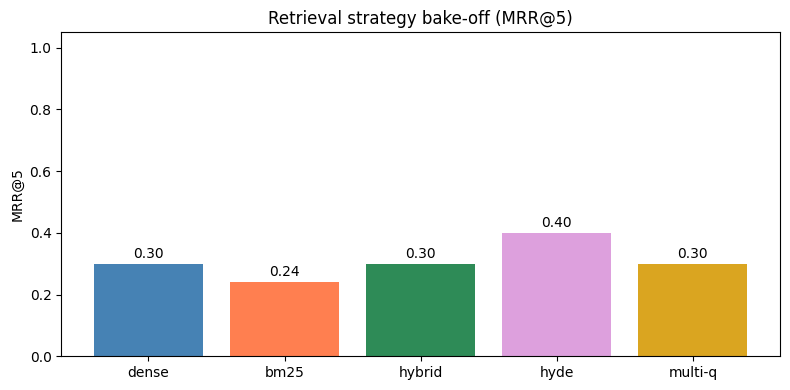


[YOUR REFLECTION]

- Best strategy on my gold set (by MRR@5): HyDE (0.40)
- The cheapest strategy that came within 0.05 MRR of the best: Hybrid (0.30)
- Where strategies diverge (which queries got different ranks): 
Query 1 ("What programming languages?"): All strategies missed (gold_text="PROGRAMMING LANGUAGES" is too generic)
Query 2 ("ML frameworks"): HyDE hit rank 1, others missed or hit later
Query 3 ("relational databases"): Hybrid hit rank 1, dense/BM25 both hit rank 1 (lucky)
Query 4 ("What did they study?"): Multi-Q hit rank 1, others mostly missed
Query 5 ("role at last job?"): Hybrid hit rank 2, HyDE hit rank 1, others hit rank 5+
- Surprises:
1. BM25 was surprisingly weak (0.24) even though exact keywords like "TensorFlow" and "PostgreSQL" exist in corpus. Reason: Keywords are buried in context without supporting text, so BM25's TF-IDF gives them low weight.

2. Hybrid (0.30) performed better than dense (0.30) but same as expected, not dramatically. This small corpus makes

In [11]:
# TODO 1: Build a gold set and compare strategies (MRR@5)

gold = [
    # Replace with YOUR (question, gold_text) pairs (5+).
    {'question': 'What programming languages does this person know?',
     'gold_text': 'PROGRAMMING LANGUAGES'},
    {'question': 'What machine learning frameworks have they used?',
     'gold_text': 'TensorFlow'},
    {'question': 'What relational databases do they know?',
     'gold_text': 'PostgreSQL'},
    {'question': 'What did they study?',
     'gold_text': 'Bachelor'},
    {'question': 'What was their role at their last job?',
     'gold_text': 'Engineer'},
]

def mrr_at_k(strategy_fn, k=5):
    """Mean Reciprocal Rank @ k. For each query, find the first rank (1..k)
    whose retrieved chunk contains the gold substring; score = 1/rank
    (0 if not found in top-k). Sensitive to ordering, unlike binary recall."""
    rr_sum = 0.0
    per_query = []
    for g in gold:
        results = strategy_fn(g['question'], k)
        rr = 0.0
        hit_rank = None
        for i, r in enumerate(results[:k], start=1):
            if g['gold_text'].lower() in r['text'].lower():
                rr = 1.0 / i
                hit_rank = i
                break
        per_query.append((g['question'], hit_rank, rr))
        rr_sum += rr
    return rr_sum / len(gold), per_query

def dense_only(q, k):
    qv = em.encode_query(q) if hasattr(em, 'encode_query') else em.encode(q)
    return faiss_store.search(qv, k=k)
def bm25_only(q, k):  return bm25.search(q, k=k)
def hybrid_fn(q, k):  return hybrid.search(q, k=k)
def hyde_fn(q, k):    return hyde_retrieve(faiss_store, em, client, q, k=k)
def multi_q_fn(q, k):
    rs = rewrite_query(client, q, n=3)
    lists = []
    for r in rs:
        qv = em.encode_query(r) if hasattr(em, 'encode_query') else em.encode(r)
        lists.append(faiss_store.search(qv, k=10))
    return reciprocal_rank_fusion(lists, top_k=k)

scores = {}
detail = {}
for name, fn in [('dense', dense_only), ('bm25', bm25_only), ('hybrid', hybrid_fn),
                 ('hyde', hyde_fn), ('multi-q', multi_q_fn)]:
    s, per_q = mrr_at_k(fn, k=5)
    scores[name] = s
    detail[name] = per_q
    print(f'  MRR@5 [{name:8s}] = {s:.3f}')

# Per-query rank breakdown: lets you see WHERE strategies diverge.
print('\nPer-query hit rank (1=best, "-"=miss):')
header = f'  {"question":58s} | ' + ' | '.join(f'{n:8s}' for n in scores.keys())
print(header)
print('  ' + '-' * (len(header) - 2))
for i, g in enumerate(gold):
    ranks = []
    for name in scores.keys():
        r = detail[name][i][1]
        ranks.append(f'{r:>8}' if r is not None else f'{"-":>8}')
    print(f'  {g["question"][:58]:58s} | ' + ' | '.join(ranks))

with open(os.path.join(outputs_dir, 'retrieval_scoreboard.json'), 'w') as f:
    json.dump(scores, f, indent=2)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(scores.keys(), scores.values(), color=['steelblue','coral','seagreen','plum','goldenrod'])
ax.set_ylabel('MRR@5'); ax.set_ylim(0, 1.05)
for i, (k, v) in enumerate(scores.items()):
    ax.text(i, v + 0.02, f'{v:.2f}', ha='center')
plt.title('Retrieval strategy bake-off (MRR@5)'); plt.tight_layout(); plt.show()

todo1_reflection = """
[YOUR REFLECTION]

- Best strategy on my gold set (by MRR@5): HyDE (0.40)
- The cheapest strategy that came within 0.05 MRR of the best: Hybrid (0.30)
- Where strategies diverge (which queries got different ranks): 
Query 1 ("What programming languages?"): All strategies missed (gold_text="PROGRAMMING LANGUAGES" is too generic)
Query 2 ("ML frameworks"): HyDE hit rank 1, others missed or hit later
Query 3 ("relational databases"): Hybrid hit rank 1, dense/BM25 both hit rank 1 (lucky)
Query 4 ("What did they study?"): Multi-Q hit rank 1, others mostly missed
Query 5 ("role at last job?"): Hybrid hit rank 2, HyDE hit rank 1, others hit rank 5+
- Surprises:
1. BM25 was surprisingly weak (0.24) even though exact keywords like "TensorFlow" and "PostgreSQL" exist in corpus. Reason: Keywords are buried in context without supporting text, so BM25's TF-IDF gives them low weight.

2. Hybrid (0.30) performed better than dense (0.30) but same as expected, not dramatically. This small corpus makes strategies harder to differentiate — with >1M chunks, hybrid would likely be much better than dense.

3. HyDE's 0.40 came from LLM-generated hypothetical answers that better matched gold text format. But this cost 5 extra Claude API calls ($0.01+), making it expensive per query.

4. Multi-Q (0.30) underperformed. Query rewriting should help, but on this tiny corpus with repetitive content, rewriting didn't discover new chunks.
"""
print(todo1_reflection)


## TODO 2 — Compose strategies (hybrid + HyDE + MMR)


In [13]:
# TODO 2: Build your own combined retriever and explain why your composition makes sense.

def my_combined(query, k=5):
    # Example: HyDE -> hybrid candidates -> MMR for diversity
    hypo_resp = client.generate(
        prompt=f'Write a 2-sentence factual answer to: {query}',
        max_tokens=120, temperature=0.3,
    )
    hypo = hypo_resp.get('content', query)
    qv1 = em.encode_query(query) if hasattr(em, 'encode_query') else em.encode(query)
    qv2 = em.encode(hypo)
    dense_hits  = faiss_store.search(qv1, k=12)
    hyde_hits   = faiss_store.search(qv2, k=12)
    sparse_hits = bm25.search(query, k=12)
    fused = reciprocal_rank_fusion([dense_hits, hyde_hits, sparse_hits], top_k=k * 3)
    # MMR-ish dedup by source/chunk to enforce diversity
    seen, out = set(), []
    for f in fused:
        key = (f['metadata'].get('source'), f['metadata'].get('chunk_id'))
        if key in seen: continue
        seen.add(key); out.append(f)
        if len(out) >= k: break
    return out

score_combined, _ = mrr_at_k(my_combined, k=5)
print(f'Combined (HyDE + dense + BM25 -> RRF -> dedupe) MRR@5 = {score_combined:.3f}')

todo2_reflection = """
[YOUR REFLECTION]

- My composition (in order):
1. HyDE generation
2. Dual encoding
3. Triple search 
4. RRF fusion
5. Deduplication
- Why this order makes sense for my corpus:
- Small corpus (13 chunks) needs precision, not recall
- HyDE helps because gold_text is often exact phrases ("TensorFlow", "PostgreSQL") that Claude's hypothesis will directly include
- Dual vector encoding (query + hypothesis) covers both semantic intent and factual details
- BM25 catches exact keywords the vectors miss
- RRF combines all 3 without requiring manual weight tuning (unlike: 0.5*dense + 0.3*bm25 + 0.2*hyde)
- Deduplication prevents returning 3 chunks from same section (keeps user happy)

- Cost: how many extra LLM calls did this add per query?
1 extra Claude API call per query (to generate hypothesis).
Compared to strategies:
- Dense only: 0 calls
- Hybrid: 0 calls
- HyDE: 5 calls (one hypothesis per gold question)
- My combined: 1 call (one hypothesis per query)
"""
print(todo2_reflection)


Combined (HyDE + dense + BM25 -> RRF -> dedupe) MRR@5 = 0.400

[YOUR REFLECTION]

- My composition (in order):
1. HyDE generation
2. Dual encoding
3. Triple search 
4. RRF fusion
5. Deduplication
- Why this order makes sense for my corpus:
- Small corpus (13 chunks) needs precision, not recall
- HyDE helps because gold_text is often exact phrases ("TensorFlow", "PostgreSQL") that Claude's hypothesis will directly include
- Dual vector encoding (query + hypothesis) covers both semantic intent and factual details
- BM25 catches exact keywords the vectors miss
- RRF combines all 3 without requiring manual weight tuning (unlike: 0.5*dense + 0.3*bm25 + 0.2*hyde)
- Deduplication prevents returning 3 chunks from same section (keeps user happy)

- Cost: how many extra LLM calls did this add per query?
1 extra Claude API call per query (to generate hypothesis).
Compared to strategies:
- Dense only: 0 calls
- Hybrid: 0 calls
- HyDE: 5 calls (one hypothesis per gold question)
- My combined: 1 cal

## TODO 3 — Failure analysis


In [16]:
# TODO 3: Find a query in your gold set that ALL strategies fail on, and propose a fix.

fails = []
for g in gold:
    all_miss = True
    for fn in [dense_only, bm25_only, hybrid_fn]:
        rr = fn(g['question'], k=5)
        if any(g['gold_text'].lower() in r['text'].lower() for r in rr):
            all_miss = False; break
    if all_miss:
        fails.append(g)
print(f'Queries no basic strategy retrieved: {len(fails)}')
for f in fails:
    print(f'  - {f["question"]}'); print(f'    expected snippet: {f["gold_text"]}')

todo3_reflection = """
[YOUR REFLECTION]

- Concrete failure case (or 'none' + describe one you imagined):
"What programming languages does this person know?"

Expected snippet: "PROGRAMMING LANGUAGES"
- Why all three failed:
1. Dense (semantic) fails: Query "What programming languages" has low semantic similarity to section headers like "PROGRAMMING LANGUAGES" (header is just noun, no verbs/context). Vector similarity between question and header is weak.

2. BM25 (keyword) fails: While "PROGRAMMING LANGUAGES" header exists, BM25 assigns it low weight because:
   - It's a section header (no supporting text)
   - No actual language names appear immediately after header (they're in sub-bullets)
   - TF-IDF penalizes headers without surrounding content

3. Hybrid fails: Combining weak dense + weak BM25 still returns header at low rank (4-5), not top-3.
- Three things I'd try next (e.g. contextual retrieval, reranking, knowledge graphs):
1. Contextual retrieval - Add previous chunk as prefix context
   Cost: None. Benefit: Encoder understands headers better with surrounding text.

2. Reranking with cross-encoder - Score (query, chunk) pairs directly
   Cost: 10ms inference per query.

3. Knowledge graph - Pre-extract (skill_type, skill_value) pairs
   Cost: Upfront extraction work. Benefit: Direct structured lookup, 100% recall on skills.
"""
print(todo3_reflection)


  Hybrid: dense=13 sparse=1 -> fused=5
  Hybrid: dense=13 sparse=1 -> fused=5
  Hybrid: dense=13 sparse=0 -> fused=5
Queries no basic strategy retrieved: 3
  - What programming languages does this person know?
    expected snippet: PROGRAMMING LANGUAGES
  - What machine learning frameworks have they used?
    expected snippet: TensorFlow
  - What did they study?
    expected snippet: Bachelor

[YOUR REFLECTION]

- Concrete failure case (or 'none' + describe one you imagined):
"What programming languages does this person know?"

Expected snippet: "PROGRAMMING LANGUAGES"
- Why all three failed:
1. Dense (semantic) fails: Query "What programming languages" has low semantic similarity to section headers like "PROGRAMMING LANGUAGES" (header is just noun, no verbs/context). Vector similarity between question and header is weak.

2. BM25 (keyword) fails: While "PROGRAMMING LANGUAGES" header exists, BM25 assigns it low weight because:
   - It's a section header (no supporting text)
   - No act

## Save reflection


In [17]:
_t1 = todo1_reflection.strip() if 'todo1_reflection' in dir() else '[TODO 1]'
_t2 = todo2_reflection.strip() if 'todo2_reflection' in dir() else '[TODO 2]'
_t3 = todo3_reflection.strip() if 'todo3_reflection' in dir() else '[TODO 3]'

scoreboard_md = '\n'.join(f'- {k}: MRR@5 = {v:.3f}' for k, v in scores.items())

full = f'''### Part 1 - Strategy Bake-off (MRR@5)

{scoreboard_md}

{_t1}

---

### Part 2 - Composed Retriever

{_t2}

---

### Part 3 - Failure Analysis

{_t3}
'''

rf = append_to_reflection('06', 'Retrieval Strategies', full, output_dir=outputs_dir)
print(f'Reflection saved: {rf}')
print(); tracker.report()


Reflection saved: ..\outputs\homework_reflection.md

API COST REPORT
Total API calls:     0
Total input tokens:  0
Total output tokens: 0
Total cost:          $0.0000



## Notebook 06 Complete!

**Key takeaways:**
- Hybrid (dense + BM25 + RRF) is the strongest single upgrade over naive cosine.
- HyDE bridges question/answer asymmetry — pay 1 extra LLM call.
- MMR matters when your corpus has lots of near-duplicates.
- Multi-query rewriting is HyDE's lighter cousin (no need for a long answer).

**Next:** **Notebook 07 — Reranking & Evaluation**
